In [1]:
from dotenv import find_dotenv, load_dotenv

# Searches parent folders until it finds "local.env"
load_dotenv(find_dotenv("local.env"))

# Configure Hugging Face and Flower caches to persist strictly in local data/ folder
from utils.data_processing import configure_hf_cache_dir

configure_hf_cache_dir()

PosixPath('/Users/bernard/Developer/ACADEMIA/research/data/raw')

In [2]:
import tqdm as notebook_tqdm
from datasets.utils.logging import enable_progress_bar
from flwr_datasets import FederatedDataset

enable_progress_bar()

## **1. All ```flwr``` datasets**

In [3]:
image_datasets = [
    "ylecun/mnist",
    "uoft-cs/cifar10",
    "uoft-cs/cifar100",
    "zalando-datasets/fashion_mnist",
    "flwrlabs/femnist",
    "zh-plus/tiny-imagenet",
    "flwrlabs/usps",
    "flwrlabs/pacs",
    "flwrlabs/cinic10",
    "flwrlabs/caltech101",
    "flwrlabs/office-home",
    "flwrlabs/fed-isic2019",
    "ufldl-stanford/svhn",
    "sasha/dog-food",
    "Mike0307/MNIST-M",
]

In [4]:
audio_datasets = [
    "google/speech_commands",
    "google/speech_commands",
    "flwrlabs/ambient-acoustic-context",
    "fixie-ai/common_voice_17_0",
    "fixie-ai/librispeech_asr",
]

In [5]:
tabular_datasets = [
    "scikit-learn/adult-census-income",
    "jlh/uci-mushrooms",
    "scikit-learn/iris",
    "jiahborcn/chembl_aqsol",
    "jiahborcn/chembl_multiassay_activity",
]

In [6]:
text_datasets = [
    "google-research-datasets/mbpp",
    "openai/openai_humaneval",
    "lukaemon/mmlu",
    "takala/financial_phrasebank",
    "pauri32/fiqa-2018",
    "zeroshot/twitter-financial-news-sentiment",
    "bigbio/pubmed_qa",
    "openlifescienceai/medmcqa",
    "bigbio/med_qa",
]

In [7]:
multimodal_datasets = ["panitsasi/fedjam"]

## **2. All ```flwr``` partitioners**

In [8]:
base_partitioners = [
    "Partitioner",
    "IidPartitioner",
    "NaturalIdPartitioner",
    "GroupedNaturalIdPartitioner",
]

In [9]:
label_partitioners = [
    "DirichletPartitioner",
    "InnerDirichletPartitioner",
    "PathologicalPartitioner",
    "ShardPartitioner",
    "DistributionPartitioner",
    "ContinuousPartitioner",
]

In [10]:
client_size_partitioners = [
    "SizePartitioner",
    "LinearPartitioner",
    "SquarePartitioner",
    "ExponentialPartitioner",
    "IdToSizeFncPartitioner",
]

In [11]:
feature_partitioners = ["VerticalEvenPartitioner", "VerticalSizePartitioner"]

## **3. Flower Datasets (`flwr_datasets`) Partitioner Decision Guide**

Partitioners divide centralized datasets to simulate federated learning client data distributions across nodes.

---



### **A. Quick Decision Matrix**

| Scenario / Simulation Goal | Recommended Partitioner | Key Parameters |
| :--- | :--- | :--- |
| **Baseline / Ideal Scenario (IID)** | `IidPartitioner` | `num_partitions` |
| **Realistic Label Distribution Skew** | `DirichletPartitioner` | `num_partitions`, `partition_by`, `alpha` |
| **Controlled Multi-Class Label Skew** | `InnerDirichletPartitioner` | `partition_sizes`, `partition_by`, `alpha` |
| **Extreme Label Skew (Fixed classes/client)** | `PathologicalPartitioner` | `num_partitions`, `partition_by`, `num_classes_per_partition` |
| **Shard-based Partitioning (FedAvg paper style)** | `ShardPartitioner` | `num_partitions`, `partition_by`, `num_shards_per_partition` |
| **Custom Label/Feature Distributions** | `DistributionPartitioner` | `distribution_array`, `partition_by` |
| **Continuous Target/Feature Skew** | `ContinuousPartitioner` | `num_partitions`, `partition_by`, `strictness` |
| **Real-world User/Client Metadata IDs** | `NaturalIdPartitioner` | `partition_by` |
| **Grouped Metadata IDs** | `GroupedNaturalIdPartitioner` | `partition_by`, `group_size` |
| **Quantity Skew (Fixed specific sample counts)** | `SizePartitioner` | `partition_sizes` |
| **Quantity Skew (Deterministic progressions)** | `LinearPartitioner`, `SquarePartitioner`, `ExponentialPartitioner` | `num_partitions` |
| **Custom Formula Quantity Skew** | `IdToSizeFncPartitioner` | `num_partitions`, custom sizing function |
| **Vertical Federated Learning (Split Features)** | `VerticalEvenPartitioner`, `VerticalSizePartitioner` | `num_partitions` or partition feature counts |

---


### **B. When to Use Which Partitioner**

#### 1. Baseline & Real-World Grouping
- **`Partitioner`**: Abstract base class. Use this only when creating custom partitioning logic from scratch.
- **`IidPartitioner`**: Uniform, random sampling across all clients. Use as the standard baseline to verify model convergence before introducing data heterogeneity.
- **`NaturalIdPartitioner`**: Splits data directly by existing client identifiers (e.g., `user_id`, `speaker_id`, or `character_id` in LEAF/Shakespeare benchmarks).
- **`GroupedNaturalIdPartitioner`**: Aggregates multiple natural IDs into pooled client partitions when individual natural IDs have too few samples.

#### 2. Label Distribution Heterogeneity (Horizontal FL)
- **`DirichletPartitioner`**: Standard statistical method in FL research (LDA-based). Use when simulating non-IID label shifts where clients hold varying ratios of classes.
  - α → ∞: Converges to IID.
  - $\alpha \in [0.1, 0.5]$: Severe non-IID skew.
- **`InnerDirichletPartitioner`**: Similar to `DirichletPartitioner`, but enforces predefined sample counts (`partition_sizes`) for every partition while sampling class labels via Dirichlet.
- **`PathologicalPartitioner`**: Enforces an exact number of unique classes per partition (e.g., each client only gets samples from 2 classes).
- **`ShardPartitioner`**: Sorts data by label and splits it into discrete shards, assigning a fixed number of shards to each partition (replicates McMahan et al., FedAvg).
- **`DistributionPartitioner`**: Use when you need exact mathematical control over a predetermined target distribution array across clients.
- **`ContinuousPartitioner`**: Partitions based on continuous numeric values (e.g., age, sensor readings, time) rather than discrete categorical labels.

#### 3. Quantity Imbalance (Client Size Skew)
- **`SizePartitioner`**: Explicitly set the number of rows/samples for each client (e.g., `partition_sizes=[5000, 1000, 200]`).
- **`LinearPartitioner`**: Sizes scale linearly with partition ID (`Size ∝ ID`).
- **`SquarePartitioner`**: Sizes scale quadratically with partition ID (`Size ∝ ID²`).
- **`ExponentialPartitioner`**: Sizes scale exponentially (`Size ∝ exp(ID)`), simulating scenarios where a few powerhouse clients dominate the dataset.
- **`IdToSizeFncPartitioner`**: Base class for implementing arbitrary mathematical functions that map partition IDs to dataset sizes.

#### 4. Feature Splitting (Vertical FL)
- **`VerticalEvenPartitioner`**: Splits columns (features) equally among clients while keeping sample row IDs aligned.
- **`VerticalSizePartitioner`**: Splits columns (features) into partitions with custom amounts of features per partition.

---


### **C. Quickstart Code Example**

```python
from flwr_datasets import FederatedDataset
from flwr_datasets.partitioner import DirichletPartitioner

# Simulating 10 clients with non-IID label skew on CIFAR-10
partitioner = DirichletPartitioner(
    num_partitions=10,
    partition_by="label",
    alpha=0.3,
    min_partition_size=10,
    shuffle=True,
    seed=42,
)

fds = FederatedDataset(
    dataset="uoft-cs/cifar10",
    partitioners={"train": partitioner}
)

# Load data for client 0
client_0_train = fds.load_partition(partition_id=0, split="train")
```


## **4. Demonstration on how to fetch and use the ```flwr``` datasets and partitioners**

### **A. Partitioning the dataset**

In [12]:
# Baseline and real-world partitioning

from flwr_datasets.partitioner import (
    GroupedNaturalIdPartitioner,
    IidPartitioner,
    NaturalIdPartitioner,
    Partitioner,
)

In [13]:
# Label based partitioning

from flwr_datasets.partitioner import (
    ContinuousPartitioner,
    DirichletPartitioner,
    DistributionPartitioner,
    InnerDirichletPartitioner,
    PathologicalPartitioner,
    ShardPartitioner,
)

In [14]:
# Client-size based partitioning

from flwr_datasets.partitioner import (
    ExponentialPartitioner,
    IdToSizeFncPartitioner,
    LinearPartitioner,
    SizePartitioner,
    SquarePartitioner,
)

In [15]:
# Feature based partitioning

from flwr_datasets.partitioner import VerticalEvenPartitioner, VerticalSizePartitioner

In [16]:
# Simulating 10 clients with non-IID label skew on CIFAR-10
partitioner = DirichletPartitioner(
    num_partitions=10,
    partition_by="label",
    alpha=0.3,
    min_partition_size=10,
    shuffle=True,
    seed=42,
)

In [17]:
print(image_datasets)
print(audio_datasets)
print(tabular_datasets)
print(text_datasets)
print(multimodal_datasets)

['ylecun/mnist', 'uoft-cs/cifar10', 'uoft-cs/cifar100', 'zalando-datasets/fashion_mnist', 'flwrlabs/femnist', 'zh-plus/tiny-imagenet', 'flwrlabs/usps', 'flwrlabs/pacs', 'flwrlabs/cinic10', 'flwrlabs/caltech101', 'flwrlabs/office-home', 'flwrlabs/fed-isic2019', 'ufldl-stanford/svhn', 'sasha/dog-food', 'Mike0307/MNIST-M']
['google/speech_commands', 'google/speech_commands', 'flwrlabs/ambient-acoustic-context', 'fixie-ai/common_voice_17_0', 'fixie-ai/librispeech_asr']
['scikit-learn/adult-census-income', 'jlh/uci-mushrooms', 'scikit-learn/iris', 'jiahborcn/chembl_aqsol', 'jiahborcn/chembl_multiassay_activity']
['google-research-datasets/mbpp', 'openai/openai_humaneval', 'lukaemon/mmlu', 'takala/financial_phrasebank', 'pauri32/fiqa-2018', 'zeroshot/twitter-financial-news-sentiment', 'bigbio/pubmed_qa', 'openlifescienceai/medmcqa', 'bigbio/med_qa']
['panitsasi/fedjam']


In [18]:
from utils.data_processing import get_federated_dataset

# Fetch the dataset backed by local data/
fds = get_federated_dataset("cifar10", partitioners={"train": partitioner})
fds

### **B. Compute counts and Compute Frequencies**

In [19]:
from flwr_datasets.metrics import compute_counts, compute_frequencies

counts_dataframe = compute_counts(
    partitioner=fds.partitioners["train"], column_name="label"
)
counts_dataframe.head()

,0,1,2,3,4,5,6,7,8,9
Partition ID,,,,,,,,,,
0,737,411,1327,349,713,388,22,1894,12,8
1,1277,3078,88,0,5,2,1,5,3,778
2,0,461,10,15,4,407,2,1,75,19
3,687,2,997,1804,142,108,149,45,1217,1951
4,2,383,648,1,39,17,2147,2,135,428


In [20]:
counts_dataframe = compute_frequencies(partitioner=partitioner, column_name="label")
counts_dataframe.head()

,0,1,2,3,4,5,6,7,8,9
Partition ID,,,,,,,,,,
0,0.125746,0.070125,0.226412,0.059546,0.121652,0.066200,0.003754,0.323153,0.002047,0.001365
1,0.243842,0.587741,0.016804,0.000000,0.000955,0.000382,0.000191,0.000955,0.000573,0.148558
2,0.000000,0.463783,0.010060,0.015091,0.004024,0.409457,0.002012,0.001006,0.075453,0.019115
3,0.096733,0.000282,0.140383,0.254013,0.019994,0.015207,0.020980,0.006336,0.171360,0.274711
4,0.000526,0.100736,0.170437,0.000263,0.010258,0.004471,0.564703,0.000526,0.035508,0.112572


### **C. Analyzing Partition Distributions (`compute_counts` vs `compute_frequencies`)**

When simulating Federated Learning, datasets are divided across multiple simulated clients (partitions). To verify the degree of **non-IID heterogeneity** (data skew), Flower provides two metric utilities:

#### 1. `compute_counts` (Absolute Frequencies)
* **What it does:** Returns a DataFrame where rows are **Partition IDs** (clients) and columns are **Classes/Labels**.
* **Cell values:** The **exact number of samples** of that class belonging to that partition.
* **Use case:** Identify **quantity skew** (which clients have more data overall) and raw class representation.

#### 2. `compute_frequencies` (Relative Distributions)
* **What it does:** Normalizes the counts so that every row sums up to **1.0** (100%).
* **Cell values:** The **proportion / ratio** ($\frac{\text{class\_count}}{\text{partition\_size}}$) of each label within that partition.
* **Use case:** Inspect **label distribution skew** (e.g., Dirichlet α effects) regardless of the partition's total size.

<font size="2" color="red">**Tip:** Pass `verbose_names=True` to replace numeric IDs (`0, 1, ...`) with human-readable class names (e.g., `"cat"`, `"dog"`).</font>


### **D. Plotting the label distributions of the federated dataset**

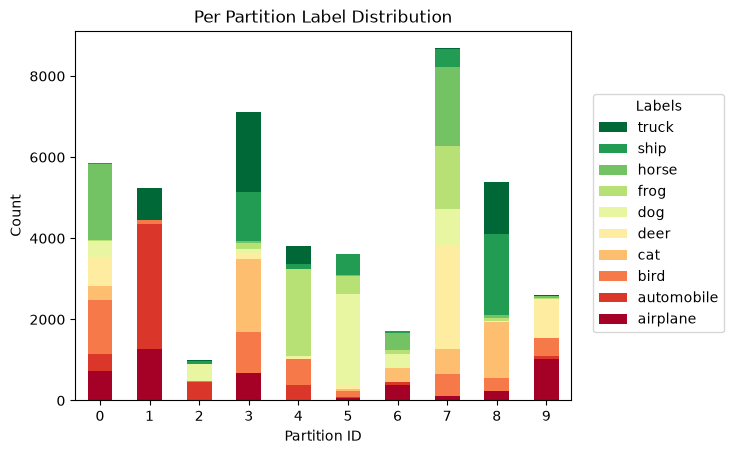

In [21]:
from flwr_datasets.visualization import plot_label_distributions

_ = plot_label_distributions(
    partitioner=fds.partitioners["train"],
    label_name="label",
    legend=True,
)